# Data Integrity Pipeline: Output Inspection
This notebook inspects the outputs produced by `data_pipeline/validate.py`.

The analysis verifies:
- reasons for rejected files;
- duplicate and cross-split leakage detection;
- class and subclass distributions after duplicate removal;
- frequency of repeated images;
- visual examples of rejected and retained duplicate pairs.

Tables and figures used for project documentation are saved to `reports/figures/`.

In [1]:
import sys
from pathlib import Path

# Locate project root from notebooks/
PROJ_ROOT = Path.cwd().parent

# Make the project package importable
sys.path.insert(0, str(PROJ_ROOT))

print(PROJ_ROOT)

c:\Users\marib\OneDrive - ITU\Desktop\ITU MATERIAL\SEMESTER 5\TAED2\taed2-GAN-Busters


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from gan_busters.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

rejected_records = pd.read_csv(PROCESSED_DATA_DIR / "rejected_records.csv")
accepted_records = pd.read_csv(PROCESSED_DATA_DIR / "accepted_records.csv")

### 1. Rejected files

Inspect the number of files rejected by the data integrity pipeline and the
reason for each rejection.

In [3]:
rejection_counts = rejected_records["reason"].value_counts()

rejection_counts.to_csv(
    TABLES_DIR / "rejection_counts.csv",
    header=["count"]
)

rejection_counts

reason
duplicate_same_split    958
cross_split_leakage     378
Name: count, dtype: int64

### 2. Distribution of the validated dataset

Inspect the distribution of accepted observations across target labels,
predefined splits, and CIFAR-10 semantic subclasses.

In [4]:
pd.crosstab(
    accepted_records["label"],
    accepted_records["split"],
    margins=True
)

split,test,train,All
label,,,
FAKE,9962,48702,58664
REAL,10000,50000,60000
All,19962,98702,118664


In [5]:
dataset_distribution = pd.crosstab(
    [accepted_records["label"], accepted_records["split"]],
    accepted_records["subclass"],
    margins=True
)

dataset_distribution.to_csv(
    TABLES_DIR / "dataset_distribution.csv"
)

dataset_distribution

subclass     airplane  automobile   bird    cat   deer    dog   frog  horse  \
label split                                                                   
FAKE  test       1000        1000    989   1000   1000    983    990   1000   
      train      5000        5000   4610   5000   5000   4538   4554   5000   
REAL  test       1000        1000   1000   1000   1000   1000   1000   1000   
      train      5000        5000   5000   5000   5000   5000   5000   5000   
All             12000       12000  11599  12000  12000  11521  11544  12000   

subclass      ship  truck     All  
label split                        
FAKE  test    1000   1000    9962  
      train   5000   5000   48702  
REAL  test    1000   1000   10000  
      train   5000   5000   50000  
All          12000  12000  118664

### 3. Duplicate frequency

Duplicate records are grouped by their content hash to determine how often
the same image occurs in the original dataset.

One retained copy is added to the number of rejected copies to reconstruct
the original occurrence count for each duplicated image.

In [6]:
duplicate_frequency = (
    rejected_records
    .dropna(subset=["hash"])
    .groupby("hash")
    .size()
    .add(1)  # add the retained copy
    .value_counts()
    .sort_index()
    .rename_axis("copies_per_image")
    .reset_index(name="number_of_images")
)

duplicate_frequency.to_csv(
    TABLES_DIR / "duplicate_frequency.csv",
    index=False
)

duplicate_frequency

,copies_per_image,number_of_images
0,2,1336


### 4. Visual sanity check of duplicate resolution

One reproducible example is sampled for each duplicate rejection rule:
same-split duplication and cross-split leakage. Each rejected image is matched
to its retained copy using the content hash and displayed side by side.

Matching hashes and raw file bytes are asserted before visualization. This
provides a visual sanity check that duplicate detection and resolution behave
as intended.

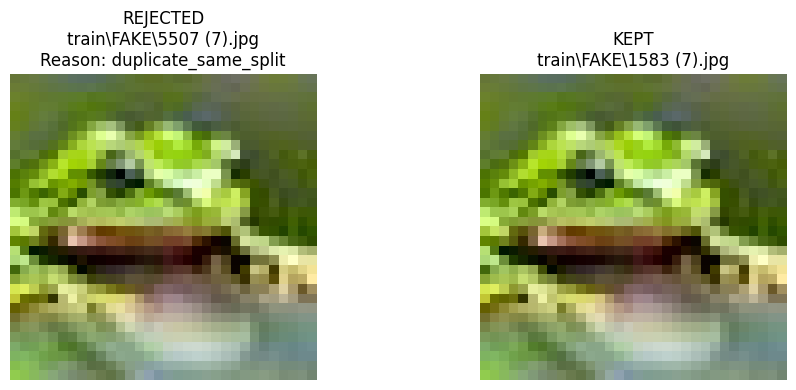

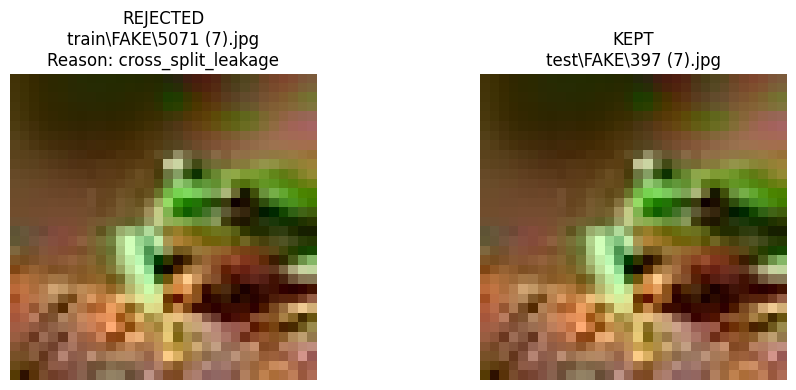

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
from gan_busters.config import RANDOM_SEED, RAW_DATA_DIR

duplicate_reasons = [
    "duplicate_same_split",
    "cross_split_leakage",
]

for reason in duplicate_reasons:

    # Select one reproducible rejected example for this duplicate case
    rejected_sample = (
        rejected_records[
            rejected_records["reason"] == reason
        ]
        .sample(1, random_state=RANDOM_SEED)
        .iloc[0]
    )

    # Find the corresponding copy that was kept
    kept_sample = accepted_records[
        accepted_records["hash"] == rejected_sample["hash"]
    ].iloc[0]

    # Locate both original files in data/raw
    rejected_path = (
        RAW_DATA_DIR / rejected_sample["relative_path"]
    )
    kept_path = (
        RAW_DATA_DIR / kept_sample["relative_path"]
    )

    # Sanity checks: both records must represent the exact same file content
    assert rejected_sample["hash"] == kept_sample["hash"]
    assert rejected_path.read_bytes() == kept_path.read_bytes()

    # Load images
    rejected_img = Image.open(rejected_path)
    kept_img = Image.open(kept_path)

    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(rejected_img)
    axes[0].set_title(
        f"REJECTED\n"
        f"{rejected_sample['relative_path']}\n"
        f"Reason: {reason}"
    )
    axes[0].axis("off")

    axes[1].imshow(kept_img)
    axes[1].set_title(
        f"KEPT\n"
        f"{kept_sample['relative_path']}"
    )
    axes[1].axis("off")

    plt.tight_layout()

    # Save reproducible report figure
    fig.savefig(
        FIGURES_DIR / f"{reason}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()